Suppose we model a population of bacteria whose rate of growth is proportional to its current size: $$\frac{dS}{dt} = \mu S$$ Solving this, we would get: $S_t = S_0e^{\mu t}$. However, stock prices do not increase exponentially, they jitter unpredictably about the growth trend, therefore we must introduce an element of randomness to the equation using a mathematical representation of Brownian motion. Let us define some term $W_t$ that has the following properties:
1. $W_0 = 0$
2. Every increment of $W$ is independant: for every $t\gt 0$ the future increments, $W_{t_u}-W_t\gt 0 $ are independant of the past values $W_s, \forall s\lt t$
3. $W$ has Gaussian (normally distributed) increments: $\forall u,t\ge 0 , W_{t+u}-W_t\sim \mathcal{N}(0,u)$. Note that the variance of the increment is dependant on the size of the increment.
4. The function $t\mapsto W_t$ is continuous

This is known as a **Wiener Process** and it will allow us to simulate the "jitters" and random motion observed in real stocks. We can do this by assuming the same upward drift, but introducing our Wiener process like so: $$dS = \mu S \: dt + \sigma S \:dW$$ Here $\sigma$ is the **volatility** of the stock, it acts as a scale factor so the magnitude of the random motions can be emphasized by more volatile stocks and suppressed by less volatile ones. Also note that the random motion is also scaled by the current stock price. This emulates real life more closely as it allows the equation to vary the stock by percentage rather than by an absolute price change (a $£1$ price swing is very different in a $£5$ stock vs a $£500$ stock, this is also why the resulting solution is in the form of a lognormal dirstibution rather than a normal one). 

Now before we proceed, we have to consider Itô's Lemma. Lets say you take some function $V(S,t)$ which represents the value of the option, and it takes the stock price $S$ and time $t$ as arguments. Now let us attempt to find the rate of change of V in relation to a changing $S$ or a changing $t$. If we attempt to solve this using the ordinary multivariable chain rule we get: $$dV = \frac{\partial V}{\partial t} dt +\frac{\partial V}{\partial S} dS$$ However, due to our Wiener process, this ordinary chain rule cannot be used (the $dW^n, n\gt 2$ terms do not vanish as it's increments are distributed normally), in its place we use Itô's Lemma, which adds an extra term to account for the random variable: $$dV = \frac{\partial V}{\partial t}dt+\frac{\partial V}{\partial S}dS+\frac{1}{2}\frac{\partial^2 V}{\partial S^2}(dS)^2$$ Now considering $dS$ from our SDE we get: $$\begin{aligned}(dS)^2 &= \underbrace{\mu^2S^2(dt)^2+2\sigma\mu S^2 \:dt \:dW}_{\text{Negligible}}+\sigma^2S^2(dW)^2\\&\approx\sigma ^2 S^2 \:dt\end{aligned}$$ The approximation holds as the first term is a factor of $dt^2$ which is negligible, however showing this for the second term is not as simple. We can find the mean of $dW$ using the moment generating function for $dW$:$$\begin{aligned}&M_X(x) = \exp\left(\mu t + \frac{\sigma^2x^2}{2}\right) = \exp{\left(\frac{dt\:x^2}{2}\right)} \\ \implies &M_X^{(1)}(x) = x\:dt\:\exp{\left(\frac{dt\:x^2}{2}\right)} \\\implies &M_X^{(2)}(x) = dt\:\exp{\left(\frac{dt\:x^2}{2}\right)}+x^2(dt)^2\exp{\left(\frac{dt\:x^2}{2}\right)}\\\implies &E[(dW)^2] = M_X^{(2)}(0) = dt \end{aligned}$$ Therefore, $(dW)^2$ is on the order of $dt$ and looking at the variance (using the standard rule) we get $\text{Var}((dW)^2) = 2(dt)^2$. Why is this useful? Lets consider this distribution over the interval $[0,T]$ and lets sum the variance and mean over $n = \frac{T}{dt}$ independant subintervals: $$\begin{gathered}E\left[\sum_i(dW_i)^2\right] = n\cdot dt = T\\ \text{Var}\left[\sum_i(dW_i)^2\right] = n\cdot 2(dt)^2 = 2T\cdot dt\end{gathered}$$ Note that the variance tends to 0 as $dt$ tends to 0 (as should be expected by the Law of Large Numbers). Therefore, the second term is on the scale of $(dt)^{3/2}$ which is also negligible. This is what permits us to use $(dW)^2 = \sigma ^2 S^2$ in Itô's Lemma. Now let us substitute our SDE and the approximation we just derived into Itô's Lemma to get:$$dV = \left(\frac{\partial V}{\partial t} + \mu S\frac{\partial V}{\partial S}+\frac{1}{2}\sigma^2S^2\frac{\partial^2 V}{\partial S^2}\right)dt + \sigma S\frac{\partial V}{\partial S}dW$$

We can then solve this SDE (stochastic differential equation. Let us set $V(S,t) = \ln S$ $$dV = \left(\mu -\frac{\sigma^2}{2}\right)dt +\sigma \:dW $$ Note that we no longer have any $S$ terms on the right hand side so we can now simply integrate across $[0,T]$ to get $$\ln S_T-\ln S_0 = \left(\mu -\frac{\sigma^2}{2}\right)T+\sigma W_T$$ We know that $W_T\sim \mathcal{N}(0, T)$. This can be rewritten by scaling the standard normal distribution $Z\sim \mathcal{N}(0,1)$ by the standard deviation of $W_T$ which is $\sqrt{T}$:$$ \therefore S_T = S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma Z\sqrt{T} \right] \quad Z\sim\mathcal{N}(0,1)$$ Let's pause here for a moment and figure out what we have calculated. We have found an analytical equation that returns a prediction for the value of a stock $S_T$ after a time $T$ from its initial value $S_0$, its volatility $\sigma$ and $\mu$. But what is $\mu$? We used it at the very beginning without really saying what it is. When we initiated it, it was the expected rate of growth of a population as a percentage of its current size, in terms of stocks, this is the expected rate of return from this specific stock on average per unit time. This value is very subjective and is, in essence, unobservable. Not very useful for our use case. To counteract this and get something that we can use we have to subsitute this value for something that is more universal.

To do this we have to **hedge** the option with something else. Let us build a portfolio as follows. Let us hold a call option of value $V$ (note this is *not* the $\ln S$ we ascribed to $V$ earlier) and short $\Delta$ shares *of the same stock*. We can represent the portfolio like so: $$\Pi = V-\Delta S$$ Applying Itô's Lemma, we can see how $\Pi$ changes over a small time step: $$d\Pi = dV-\Delta dS$$ Substituting Itô's Lemma and the SDE for $dV, dS$ respectively: $$\begin{aligned}&d\Pi = \left(\frac{\partial V}{\partial t} + \mu S\frac{\partial V}{\partial S}+\frac{1}{2}\sigma^2S^2\frac{\partial^2 V}{\partial S^2}\right)dt + \sigma S\frac{\partial V}{\partial S}dW - \Delta(\mu S\:dt+\sigma S\:dW)\\\implies
& d\Pi = \left(\frac{\partial V}{\partial t} + \mu S\left(\frac{\partial V}{\partial S}-\Delta\right)+\frac{1}{2}\sigma^2S^2\frac{\partial^2 V}{\partial S^2}\right)dt + \left(\sigma S\left(\frac{\partial V}{\partial S}-\Delta\right)\right)dW
\end{aligned}$$ We can then set $\Delta = \frac{\partial V}{\partial S}$ to get: $$d\Pi = \left(\frac{\partial V}{\partial t}+\frac{1}{2}\sigma^2S^2\frac{\partial^2 V}{\partial S^2}\right)dt$$ Note that what we have now is an entirely deterministic equation, **the random term has vanished**. We have made a portfolio that must grow at a constant rate. We have manufactured a **risk-free** portfolio. Therefore, by the **no-arbitrage** principle it must grow at the **risk-free rate** ($r$): $$\frac{d\Pi}{dt} = \frac{\partial V}{\partial t}+\frac{1}{2}\sigma^2S^2\frac{\partial^2 V}{\partial S^2} = r\Pi = r\left(V-S\frac{\partial V}{\partial S}\right)$$ Rearranging this we get the **Black-Scholes PDE**: $$\boxed{\frac{\partial V}{\partial t} +\frac{1}{2}\sigma^2S^2\frac{\partial^2V}{\partial S^2}+rS\frac{\partial V}{\partial S}-rV = 0}$$

Solving this equation subject to the call option boundary conditions: $V(S,T) = \max\{0, S-K\}$ we get the following: $$C = S\cdot N(d_1)-Ke^{-rT}\cdot N(d_2)$$ $$d_1 = \frac{\ln\left(\frac{S}{K}\right)+T\left(r+\frac{\sigma^2}{2}\right)}{\sigma\sqrt{T}}, \quad \quad d_2 = d_1-\sigma \sqrt{T}$$ When doing the same for the put option boundary conditions, $V(S,T) = \max\{0,K-S\}$, we get the same $d_1,d_2$ and: $$P = Ke^{-rT}\cdot N(-d_2)-S\cdot N(-d_1)$$ These are the equations that `analytical.py` encode in the functions `bs_call` and `bs_put`. They take in the current value of the stock $(S)$, the strike rate of the option $(K)$, the time until expiration in years $(T)$, the risk free rate $(R)$ and the volatility of the stock $(\sigma)$, and returns the fair value of the option.

In [1]:
from black_scholes.analytical import * # Importing the Black-Scholes functions
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from functools import partial
import scipy

The function and loop below are a simple check of the mathematical properties of the functions `bs_call` and `bs_put`. This check is based on the relationship between the Black-Scholes put and call calculations. Consider the portfolios:
1. **Portfolio 1:** One call option and $Ke^{-rT}$ in cash
2. **Portfolio 2:** One put option and one share of the stock

Now let us consider the following possibilities:
1. **Case 1:** $S_T\ge K\implies S_T-K\ge 0$. Then we have that $\max\{0, S_T-K\} = S_T-K$ and $\max\{0,K-S_T\} = 0$
    1. **Portfolio 1:** Valued at: $C_T+K = S_T-K+K = S_T$ at expiry
    2. **Portfolio 2:** Valued at: $P_T +S_T = 0+S_T = S_T$ at expiry
    3. Therefore the values of both portfolios are equal
2. **Case 2:** $S_T\lt K\implies S_T-K\lt 0$. Then we have that $\max\{0, S_T-K\} = 0$ and $\max\{0,K-S_T\} = K-S_T$
    1. **Portfolio 1:** Valued at: $C_T+K = 0+K = K$ at expiry
    2. **Portfolio 2:** Valued at: $P_T +S_T = K-S_T+S_T = K$ at expiry
    3. Therefore the values of both portfolios are equal

So we have that in all situations the values of the portfolios must be equal at expiry, therefore by no-arbitrage we must have that the portfolios values must be equal now. Therefore, considering values right now we have: $$C + Ke^{-rT} = P + S\implies C-P = S-Ke^{-rT}$$ This is exactly the relationship that we are testing below.

In [2]:
## Inputs for put-call parity check ##
S = [50, 80, 100, 120, 200]
K = [70, 90, 100, 110, 150]
T = [0.01, 0.1, 0.5, 1.0, 5.0]
r = [-0.02, 0.0, 0.02, 0.05, 0.10]
sigma = [0.01, 0.10, 0.20, 0.50, 1.00]

In [3]:
## Function that simply calculates the equation discussed above ##

def parity_check(S, K, T, r, sigma): 
    num = S - (K * np.e**(-r*T))
    bs_values = bs_call(S, K, T, r, sigma)-bs_put(S, K, T, r, sigma)
    return bs_values-num

In [4]:
indicator = 0
for i in product(S, K, T, r, sigma):
    a = parity_check(*i)
    if a>1e-10:
        print(f"ERROR: {i} has a difference of {a}")
        indicator = 1
if indicator == 0:
    print("Woo! It is correct")

Woo! It is correct


Below is a graph showing how the pricing of a put and call option change for varying values of $S$. The behavior shown below can also be seem by considering the original equations: $$\left.\begin{aligned}\lim_{S\to \infty} d_1 = \lim_{S\to \infty}\left[\frac{\ln\left(\frac{S}{K}\right)+T\left(r+\frac{\sigma^2}{2}\right)}{\sigma\sqrt{T}}\right]=\infty \\\lim_{S\to \infty}d_2 = \lim_{S\to \infty}\left(d_1-\sigma \sqrt{T}\right) = \infty \end{aligned}\right\}\implies \begin{aligned}&\lim_{d_1, d_2\to \infty}C = S\times 1 -Ke^{-rT}\times 1 = S-Ke^{-rT}\\&\lim_{-d_1, -d_2\to -\infty}P = Ke^{-rT}\times 0-S\times 0 = 0\end{aligned}$$
Note that there is still an $S$ in the other side of the call equation, however we are more interested in the *asymptotic* behaviour of $C$ and $P$ than the overall trend. Also we can discount the classic $0\times \infty$ issue that arises in the put call, as we know that the Gaussian distribution approaches 0 expoentially fast so when mutliplied by a linearly inreasing $S$ it tends to 0. Doing a similar calculation we can see that when $S\to 0,$ $P\to Ke^{-rT}-S$ and $C\to 0$. These graphs show the full effect of us solving the Black-Scholes PDE with the boundary conditions: $$\begin{gathered}C = \max\{0,S-K\}\\P = \max\{0,K-S\}\end{gathered}$$ These asymptotes reproduce the same functional form as the boundary contitions. This tells us that a deep in the money or out of the money outcome becomes nearly certain.

In [5]:
## Inputs for the price vs the spot price S graph ##
K = 100
T = 1.0
r = 0.05
sigma = 0.20

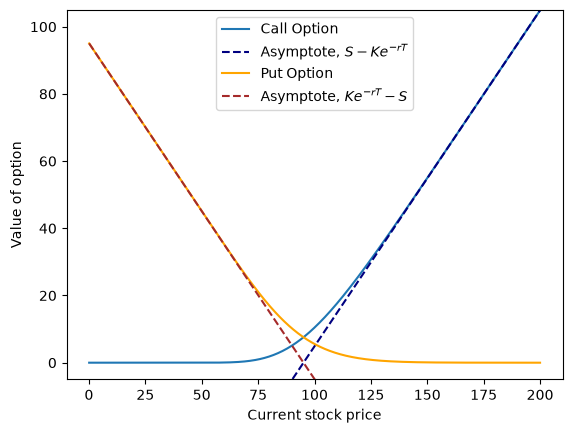

In [6]:
S_values = np.linspace(0.1,200,500)

plt.figure()

plt.plot(S_values, bs_call(S_values, K, T, r, sigma), label = "Call Option")
plt.plot(S_values , S_values-(K*(np.e**(-r*T))), "navy", linestyle='--', label = r"Asymptote, $S-Ke^{-rT}$")

plt.plot(S_values, bs_put(S_values, K, T, r, sigma), color = 'orange', label = "Put Option")
plt.plot(S_values , (K*(np.e**(-r*T)))-S_values, "brown", linestyle='--', label = r"Asymptote, $Ke^{-rT}-S$")

plt.xlabel("Current stock price")
plt.ylabel("Value of option")
plt.ylim(-5,105)
plt.legend()
plt.show()

## plt.savefig('option_S.png')

Below we are looking at the impact of increasing volatility on the option price. We can see that it is a monotonic increase from the graph, which is a fairly unintuitive result. Why does a more volatile stock lead to a more valuable option? It is due to the capped loss. There is no way to lose money by owning an option as you can choose whether to exercise it at expiry. So the loss is capped at $£0$. This means that greater spread afforded to you by a more volatile stock only makes for a potential increase in the value of that stock at expiration as it cannot decrease it. From the graph we can also see that the value of the call and put options plateus as the volatility increases, at $S$ and $Ke^{-rT}$ respectively. We can check the behaviours of the equations like so: $$\begin{gathered}\lim_{\sigma\to \infty}d_1\approx \frac{\frac{\sigma^2}{2}T}{\sigma T} = \frac {\sigma T}{2}\to \infty \implies N(d_1)\to 1\\\lim_{\sigma\to\infty}d_2 \approx \frac {\sigma T}{2}-\sigma T = -\frac {\sigma T}{2}\to -\infty\implies N(d_2)\to 0 \end{gathered}$$ From this we can see that $P\to Ke^{-rT}$ and $C\to S$. Looking at the other end (as $\sigma\to 0$) we can se similar asymptotes that arise as a result of no volatility. When there is no volatility the final price of the stock must surely be $Se^{rT}$. This quantity is known as the **forward price**. Let us consider this mathematically: $$\begin{aligned}\lim_{\sigma\to 0}d_1 \approx \frac{\ln\left(\frac{S}{K}\right)-rT}{\sigma\sqrt{T}} &= \begin{cases}\infty &\text{when }\ln\left(\frac{S}{K}\right)-rT\gt 0\\-\infty &\text{when }\ln\left(\frac{S}{K}\right)-rT\lt 0\end{cases} \\&= \begin{cases}\infty &\text{when }Se^{-rT}\gt K\\-\infty &\text{when }Se^{-rT}\lt K\end{cases}\end{aligned}$$ Note that trivially $d_2\to d_1$ as $\sigma\to 0$. From this we can see that our lower limit is dependant on the options **moneyness**:
1. **Case 1:** The options definitely end up **in the money** (i.e. $Se^{rT}\gt K$). We must have $d_1, d_2\to \infty\implies N(d_1),N(d_2)\to 1$ $$\begin{gathered}C\to S\cdot 1 - Ke^{-rT}\cdot 1 = \boxed{S-Ke^{-rT}}\\P\to Ke^{-rT}\cdot 0 - S\cdot 0 = \boxed{0}\end{gathered}$$
2. **Case 2:** The options definitely end up **out of the money** (i.e. $Se^{rT}\lt K$). We must have $d_1, d_2\to -\infty\implies N(d_1),N(d_2)\to 0$ $$\begin{gathered}C\to S\cdot 0 - Ke^{-rT}\cdot 0 = \boxed{0}\\P\to Ke^{-rT}\cdot 1 - S\cdot 1 = \boxed{Ke^{-rT}-S}\end{gathered}$$

In [7]:
## Input values for price against volatility graph ##
S = 100
K = 100
T = 1.0
r = 0.05
sigma_start, sigma_end = 0.001, 10

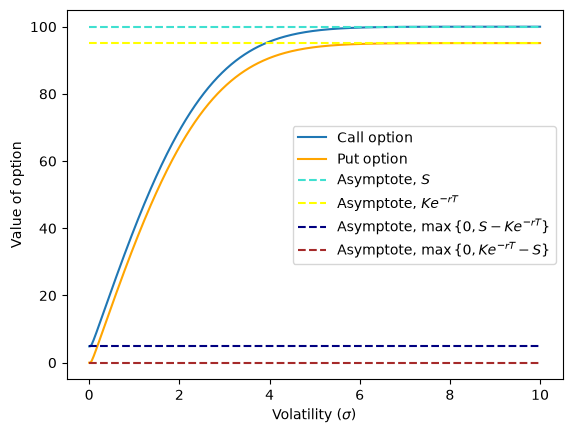

In [8]:
sigma_values = np.linspace(sigma_start, sigma_end, 500)

plt.figure()
plt.plot(sigma_values, bs_call(S, K, T, r, sigma_values), label = "Call option")
plt.plot(sigma_values, bs_put(S, K, T, r, sigma_values), color = 'orange', label = "Put option")
plt.hlines(S, 0, 10, ls = "--", color = "turquoise", label = r"Asymptote, $S$")
plt.hlines(K*(np.e**(-r*T)), 0, 10 , color = "yellow", ls = "--", label = r"Asymptote, $Ke^{-rT}$")
plt.hlines(np.max([0, S-K*(np.e**(-r*T))]), sigma_start, sigma_end, ls = "--", color = "navy", label = r"Asymptote, $\max\{0,S-Ke^{-rT}\}$")
plt.hlines(np.max([0, K*(np.e**(-r*T))-S]), sigma_start, sigma_end, color = "brown", ls = "--", label = r"Asymptote, $\max\{0,Ke^{-rT}-S\}$")
plt.xlabel('Volatility ('r'$\sigma)$')
plt.ylabel("Value of option")
plt.legend(loc = 'center right')
plt.show()

## plt.savefig('option_sigma.png')

Here we are exploring the behaviours of the put and call pricing as time until expiry changes. We can see that the put options price increases and then begins to decrease, tending towards $0$ as $T\to \infty$. On the other hand the call options price seems to tend to the current stock value, i.e. $C\to S$ as $T\to \infty$. This happens due to the differences in the rate of change between the $\sigma\sqrt{T}$ terms in our $d_1, d_2$ equations (causing a similar affect as we saw before with a changing volatility) and the $Ke^{-rT}$ term in our main pricing equations. We have that as $T\ \to \infty, d_1\to \infty$ and $d_2\to \infty$ (this is true for positive $r$ or sufficiently small $r$, you can quickly verify this youself using similar methods as we saw previously) which means that $N(d_1),N(d_2)\to 1$. This resulst in our main call equation looking like this: $$\begin{gathered}C \to S-Ke^{-rT}\to S\end{gathered}$$ Similar to what we saw as $\sigma$ increased. But what about put? We know that $d_1, d_2\to \infty \implies N(-d_1), N(-d_2)\to 0$ which means that inevitably $P\to 0$ as we can see below, but why does it have a little bump along the way? (It will print this maximum point below) This happens due to the put equation itself: $$P = Ke^{-rT}\cdot N(-d_2)-S\cdot N(-d_1)$$ As we can see in the second graph the value of $N(-d_1)$ is falling faster than $N(-d_2)$. This means that the second term which is reducing the value of $P$ is decaying faster than the value of the first term is decaying. Then once the value of $N(-d_1)$ bottoms out, the decay of $N(-d_2)$ and $\exp(-T)$ takes over once more and we see a gradual decay once more. This combination of factors leads to a "speed-bump" like shape.

In [9]:
## Input values for price against time graph ##
S = 100
K = 100
r = 0.05
sigma = 0.20
T_start, T_end = 0.001, 100

The time until expiry that gives the greatest put value is 3.98 years and it will have a value of £7.09


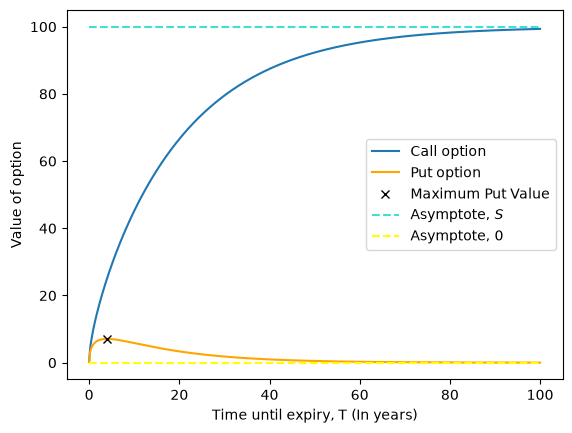

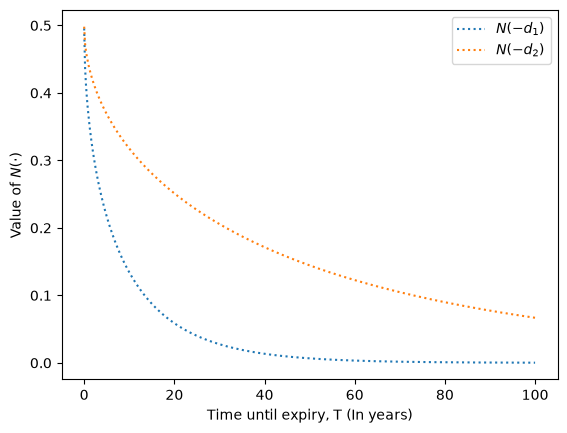

In [10]:
T_values = np.linspace(T_start,T_end,500)

fixed_func = partial(bs_put, S=S, K=K, R=r, sigma = sigma)
result = scipy.optimize.minimize_scalar(lambda T: -fixed_func(T=T), bounds=(T_start, T_end), method='bounded')
max_x = result.x
max_y = -result.fun
print(f"The time until expiry that gives the greatest put value is {max_x:.2f} years and it will have a value of £{max_y:.2f}")

plt.figure()
plt.plot(T_values, bs_call(S, K, T_values, r, sigma), label = "Call option")
plt.plot(T_values, bs_put(S, K, T_values, r, sigma), color = 'orange', label = "Put option")
plt.xlabel('Time until expiry, T (In years)')
plt.ylabel("Value of option")
plt.plot(max_x, max_y, 'x', color = 'black', label="Maximum Put Value")
plt.hlines(S, T_start, T_end, ls = "--", color = "turquoise", label = r"Asymptote, $S$")
plt.hlines(0, T_start, T_end , color = "yellow", ls = "--", label = r"Asymptote, $0$")
plt.legend()
plt.show()

## plt.savefig('option_T.png')

plt.figure()
plt.plot(T_values, scipy.stats.norm.cdf(-intermediaries(S, K, T_values, r, sigma)[0]), ls = 'dotted', label = r'$N(-d_1)$')
plt.plot(T_values, scipy.stats.norm.cdf(-intermediaries(S, K, T_values, r, sigma)[1]), ls = 'dotted', label = r'$N(-d_2)$')
plt.xlabel('Time until expiry, T (In years)')
plt.ylabel(r"Value of $N(\cdot)$")
plt.legend()
plt.show()

## plt.savefig('N_T.png')